In [26]:
# ==============================================================================
# CÉLULA 00: SETUP E DEFINIÇÃO DO DIRETÓRIO RAIZ (ROOT)
# ==============================================================================
import os
import sys

# 1. Verificação do ambiente de execução (Nuvem vs Local)
if 'google.colab' in sys.modules:
    print("☁️ Ambiente detectado: Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')

    # Insira abaixo o caminho exato onde clonou/salvou este repositório no seu Google Drive.
    caminho_projeto = '/content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub'

else:
    print("💻 Ambiente detectado: Local (Jupyter, VS Code, Spyder)")
    # Assume dinamicamente a pasta onde o notebook foi aberto como a raiz
    caminho_projeto = os.getcwd()

# 2. Configuração global do diretório de trabalho
try:
    os.chdir(caminho_projeto)
    if caminho_projeto not in sys.path:
        sys.path.append(caminho_projeto)
    print(f"✅ Diretório raiz configurado com sucesso: {os.getcwd()}")
except FileNotFoundError:
    print(f"❌ ERRO: A pasta '{caminho_projeto}' não foi encontrada.")
    print("Por favor, verifique se o caminho inserido está correto.")
    raise

☁️ Ambiente detectado: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Diretório raiz configurado com sucesso: /content/drive/MyDrive/1) PESQUISA/ESALQ Data Science/tcc/tema_classificacao_queda_arvore/git/tcc_risco_queda_v-pub


In [27]:
import pandas as pd
import geopandas as gpd
import joblib
import os
!pip install pyogrio -q

from src.spatial_utils import classificar_risco_operacional

In [28]:
from datetime import datetime, timedelta

# Defina o nome do cenário atual aqui (sem espaços, use underlines)
nome_cenario = "abrangente"

# Garante a existência da data base e adiciona o nome do cenário ao final
if 'data_hora_base' not in globals():
    data_hora_base = datetime.now().strftime("_%Y%m%d-%H%M")

sufixo_data = f"{data_hora_base}_{nome_cenario}"

print(sufixo_data)

_20260401-1802_abrangente


In [29]:
# ==============================================================================
# CÉLULA 01: CARREGAMENTO DO MASTER DATASET E DEFINIÇÃO DO ESCOPO
# ==============================================================================
import pandas as pd
import geopandas as gpd

# 1. Carregamento do Novo Master Dataset
file_path = "data/processed/dataset_MASTER.parquet"
print("📂 Carregando dataset master deduplicado...")
df_parquet = pd.read_parquet(file_path)

# Convertendo binário WKB para geometrias ativas
if isinstance(df_parquet['geometry'].iloc[0], bytes):
    df_parquet['geometry'] = gpd.GeoSeries.from_wkb(df_parquet['geometry'])

# 2. Transformar com sucesso em GeoDataFrame
df_full = gpd.GeoDataFrame(df_parquet, geometry='geometry', crs="EPSG:31983")

print(f"🌍 Base Total Carregada: {len(df_full)} segmentos viários.")

📂 Carregando dataset master deduplicado...
🌍 Base Total Carregada: 110956 segmentos viários.


In [30]:
# ==============================================================================
# CÉLULA 02: IMPORTAÇÃO DO MODELO, PREDIÇÃO E EXPORTAÇÃO (DF_MAPA)
# ==============================================================================
import os
import joblib
import geopandas as gpd

# 📥 Importação oficial da sua função vetorizada
from src.spatial_utils import classificar_risco_operacional

print("📥 1. Carregando a inteligência do modelo treinado...")
caminho_modelo = f'results/models/modelo_xgb_{nome_cenario}.pkl'
caminho_threshold = f'results/models/threshold_{nome_cenario}.pkl'
caminho_metadados = f'results/models/metadados_{nome_cenario}.pkl'

try:
    pipeline_xgb = joblib.load(caminho_modelo)
    limiar_acao = joblib.load(caminho_threshold)
    metadados = joblib.load(caminho_metadados)
except FileNotFoundError as e:
    raise FileNotFoundError(f"❌ Ficheiros do modelo não encontrados! Rode o final do notebook 02. Erro: {e}")

features_num = metadados['features_numericas']
features_cat = metadados['features_categoricas']
medianas = metadados['medianas_treino']

print("🌍 2. Aplicando o modelo otimizado para toda a malha viária de São Paulo...")
df_mapa = df_full.copy()
X_cidade = df_mapa[features_num + features_cat]

# Preenchimento de NAs com as medianas aprendidas no TREINO
X_cidade_clean = X_cidade.copy()
for col in features_num:
    X_cidade_clean[col] = X_cidade_clean[col].fillna(medianas[col])

# Prevendo probabilidade
df_mapa['Prob_Queda'] = pipeline_xgb.predict_proba(X_cidade_clean)[:, 1]

print(f"📏 3. Classificando Nível de Risco Operacional (Threshold: {limiar_acao:.2f})...")
# 🚀 REFATORAÇÃO: Usando o spatial_utils.py em vez da função manual
df_mapa['Nivel_Risco'] = classificar_risco_operacional(df_mapa['Prob_Queda'], limiar_acao)

print(df_mapa['Nivel_Risco'].value_counts().sort_index())

print("\n💾 4. Exportando resultado espacial para o disco (GeoPackage)...")
if isinstance(df_mapa['geometry'].iloc[0], bytes):
    df_mapa['geometry'] = gpd.GeoSeries.from_wkb(df_mapa['geometry'])

gdf_mapa = gpd.GeoDataFrame(df_mapa, geometry='geometry', crs="EPSG:31983")

os.makedirs('results/maps', exist_ok=True)
sufixo = sufixo_data if 'sufixo_data' in globals() else f'_{nome_cenario}'
caminho_gpkg = f'results/maps/03_atlas_risco_qgis{sufixo}.gpkg'

gdf_mapa.to_file(caminho_gpkg, driver="GPKG")
print(f"✅ Base salva fisicamente em: {caminho_gpkg}")

📥 1. Carregando a inteligência do modelo treinado...
🌍 2. Aplicando o modelo otimizado para toda a malha viária de São Paulo...
📏 3. Classificando Nível de Risco Operacional (Threshold: 0.44)...
Nivel_Risco
1 - Baixo Risco                             9070
2 - Risco Moderado                         51729
3 - Alto Risco (Prioridade de Vistoria)    43683
4 - Risco Crítico (Emergência)              6474
Name: count, dtype: int64

💾 4. Exportando resultado espacial para o disco (GeoPackage)...
✅ Base salva fisicamente em: results/maps/03_atlas_risco_qgis_20260401-1802_abrangente.gpkg


In [31]:
# ==============================================================================
# CÉLULA 03: PREDIÇÃO E EXPORTAÇÃO DO MAPA
# ==============================================================================
df_mapa = df_full.copy()
X_cidade = df_mapa[features_num + features_cat]

# Preenchimento de NAs com as medianas aprendidas no TREINO (metadados)
X_cidade_clean = X_cidade.copy()
for col in features_num:
    X_cidade_clean[col] = X_cidade_clean[col].fillna(medianas[col])

# Prevendo probabilidade
df_mapa['Prob_Queda'] = pipeline_xgb.predict_proba(X_cidade_clean)[:, 1]

print(f"\n📏 3. Classificando Nível de Risco Operacional (Threshold: {limiar_acao:.2f})...")
def classificar_risco(prob):
    if prob >= limiar_acao * 1.5: return '1. Crítico'
    elif prob >= limiar_acao:     return '2. Alto'
    elif prob >= limiar_acao * 0.5: return '3. Moderado'
    else: return '4. Baixo'

df_mapa['Nivel_Risco'] = df_mapa['Prob_Queda'].apply(classificar_risco)
print(df_mapa['Nivel_Risco'].value_counts().sort_index())

print("\n💾 4. Exportando resultado espacial para o disco (GeoPackage)...")
if isinstance(df_mapa['geometry'].iloc[0], bytes):
    df_mapa['geometry'] = gpd.GeoSeries.from_wkb(df_mapa['geometry'])

gdf_mapa = gpd.GeoDataFrame(df_mapa, geometry='geometry', crs="EPSG:31983")

os.makedirs('results/maps', exist_ok=True)
sufixo = sufixo_data if 'sufixo_data' in globals() else f'_{nome_cenario}'
caminho_gpkg = f'results/maps/03_atlas_risco_qgis{sufixo}.gpkg'

# Salva o arquivo para usar na renderização estática e no QGIS Web
gdf_mapa.to_file(caminho_gpkg, driver="GPKG")
print(f"✅ Base salva fisicamente em: {caminho_gpkg}")


📏 3. Classificando Nível de Risco Operacional (Threshold: 0.44)...
Nivel_Risco
1. Crítico     13141
2. Alto        37016
3. Moderado    51729
4. Baixo        9070
Name: count, dtype: int64

💾 4. Exportando resultado espacial para o disco (GeoPackage)...
✅ Base salva fisicamente em: results/maps/03_atlas_risco_qgis_20260401-1802_abrangente.gpkg


In [24]:
# ==============================================================================
# CÉLULA 04: EXPORTAÇÃO WEB (QGIS2WEB)
# ==============================================================================
import os
import geopandas as gpd

print("📦 Preparando arquivo otimizado para Webmapping...")

# 1. ATUALIZADO: Usamos os nomes exatos das colunas geradas pela Célula 10
colunas_web = [
    'cvc_tplogr', 'cvc_nomelg',
    'Prob_Queda',
    'Nivel_Risco',
    'geometry'
]

# 2. ATUALIZADO: Puxamos os dados do 'gdf_mapa' (e não do df_full)
gdf_webmap = gdf_mapa[colunas_web].copy()

# 3. Formatação Inteligente para o Popup (Evita duplicação do tipo de logradouro)
def limpar_endereco(row):
    tipo = str(row['cvc_tplogr']).strip()
    nome = str(row['cvc_nomelg']).strip()

    # Tratamento de nulos
    if nome in ['nan', 'None', '']: return tipo
    if tipo in ['nan', 'None', '']: return nome.title()

    # Se o nome já começar com a sigla/tipo, usamos só o nome
    if nome.lower().startswith(tipo.lower()):
        return nome.title()
    else:
        return f"{tipo} {nome}".title()

# Aplica a limpeza
gdf_webmap['endereco_busca'] = gdf_webmap.apply(limpar_endereco, axis=1)

# Formata a probabilidade para leitura humana no Popup
gdf_webmap['prob_formatada'] = (gdf_webmap['Prob_Queda'] * 100).round(1).astype(str) + "%"

# Renomeia a coluna Nivel_Risco para classe_risco para ficar limpo no QGIS
gdf_webmap.rename(columns={'Nivel_Risco': 'classe_risco'}, inplace=True)

# Mantém apenas as 4 colunas essenciais para a web
gdf_webmap = gdf_webmap[['endereco_busca', 'prob_formatada', 'classe_risco', 'geometry']]

print("✂️ Simplificando geometrias para reduzir o peso do arquivo...")
# Simplifica no formato original em metros (UTM)
gdf_webmap['geometry'] = gdf_webmap.geometry.simplify(1.0)

print("🌐 Reprojetando coordenadas para WGS84 (Padrão Web)...")
# O EPSG:4326 é pesado de gerar em bases grandes, por isso a simplificação vem antes
gdf_webmap = gdf_webmap.to_crs(epsg=4326)

# 4. Exportação
os.makedirs('results/maps', exist_ok=True)
sufixo = sufixo_data if 'sufixo_data' in globals() else ''
caminho_exportacao = f'results/maps/mapa_risco_qgis2web{sufixo}.geojson'

# Exportação ultra-rápida com o engine pyogrio
gdf_webmap.to_file(caminho_exportacao, driver='GeoJSON', engine='pyogrio')

print(f"✅ Arquivo LEVE exportado com sucesso para: {caminho_exportacao}")

📦 Preparando arquivo otimizado para Webmapping...
✂️ Simplificando geometrias para reduzir o peso do arquivo...
🌐 Reprojetando coordenadas para WGS84 (Padrão Web)...
✅ Arquivo LEVE exportado com sucesso para: results/maps/mapa_risco_qgis2web_20260401-1802_abrangente.geojson


🎨 Renderizando mapa estático de alta resolução (300 DPI)...
✅ Base encontrada na memória. Preparando plotagem...
📏 Garantindo projeção UTM (Sirgas 2000) para proporções reais...
🔍 Valores encontrados na base: {'3. Moderado', '2. Alto', '1. Crítico', '4. Baixo'}
✅ Mapa final gerado e exportado com sucesso em: results/figures/03_mapa_risco_final_sp_20260401-1802_abrangente.png


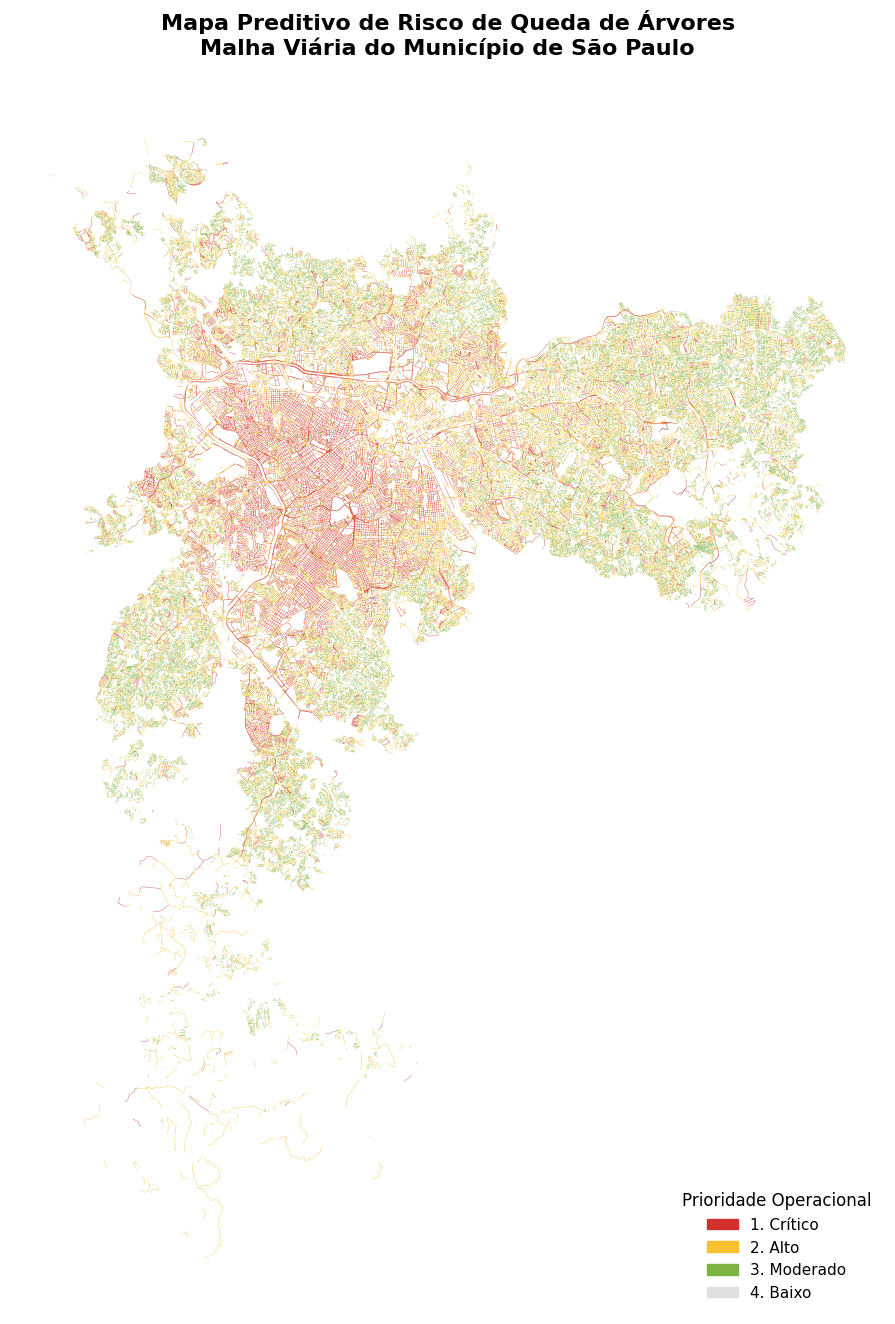

In [32]:
# ==============================================================================
# RENDERIZAÇÃO DO MAPA ESTÁTICO DE ALTA RESOLUÇÃO (PARA A DISSERTAÇÃO)
# ==============================================================================
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("🎨 Renderizando mapa estático de alta resolução (300 DPI)...")

# 1. RECUPERAÇÃO INTELIGENTE DA BASE ESPACIAL
sufixo = sufixo_data if 'sufixo_data' in globals() else f'_{nome_cenario}'
caminho_gpkg = f'results/maps/mapa_risco_sp{sufixo}.gpkg'

# Verifica se a variável já existe na memória (usando globals no lugar de locals)
if 'gdf_mapa' in globals():
    print("✅ Base encontrada na memória. Preparando plotagem...")
    gdf_plot = globals()['gdf_mapa'].copy()
elif os.path.exists(caminho_gpkg):
    print(f"📥 Variável não encontrada na memória. Carregando do disco: {caminho_gpkg}...")
    gdf_plot = gpd.read_file(caminho_gpkg)
else:
    raise FileNotFoundError("❌ Base de dados não encontrada. Rode a Célula 4 primeiro!")

# CORREÇÃO CARTOGRÁFICA
print("📏 Garantindo projeção UTM (Sirgas 2000) para proporções reais...")
gdf_plot = gdf_plot.to_crs("EPSG:31983")

# ---------------------------------------------------------
# 🚨 BLOCO DE DIAGNÓSTICO (Avisa se os nomes não baterem)
# ---------------------------------------------------------
if 'Nivel_Risco' not in gdf_plot.columns:
    raise KeyError(f"❌ A coluna 'Nivel_Risco' não existe! Colunas disponíveis: {gdf_plot.columns.tolist()}")

valores_base = set(gdf_plot['Nivel_Risco'].dropna().unique())
print(f"🔍 Valores encontrados na base: {valores_base}")
# ---------------------------------------------------------

# 2. PLOTAGEM DO MAPA
fig, ax = plt.subplots(figsize=(12, 16))

# ⚠️ ATUALIZADO: Usando exatamente as strings que estão na base de dados
paleta_risco = {
    '1. Crítico': '#D32F2F',    # Vermelho Carmim
    '2. Alto': '#FBC02D',       # Amarelo Ouro
    '3. Moderado': '#7CB342',   # Verde Maçã
    '4. Baixo': '#E0E0E0'       # Cinza Neutro
}

# Ordem de plotagem: Baixo para Cima (Garante que o Crítico seja desenhado por cima de tudo)
ordem_plotagem = [
    '4. Baixo',
    '3. Moderado',
    '2. Alto',
    '1. Crítico'
]

# Variável de controle para saber se algo foi plotado
linhas_plotadas = 0

for nivel in ordem_plotagem:
    subset = gdf_plot[gdf_plot['Nivel_Risco'] == nivel]
    if not subset.empty:
        # ⚠️ ATUALIZADO: Condição ajustada para a string correta
        espessura = 0.4 if nivel == '4. Baixo' else 0.8
        subset.plot(ax=ax, color=paleta_risco[nivel], linewidth=espessura)
        linhas_plotadas += len(subset)

# Estética Acadêmica
ax.set_axis_off()
ax.set_title('Mapa Preditivo de Risco de Queda de Árvores\nMalha Viária do Município de São Paulo',
             fontsize=16, pad=20, weight='bold')

# Legenda Manual
legend_patches = [mpatches.Patch(color=paleta_risco[n], label=n) for n in ordem_plotagem[::-1]]
ax.legend(handles=legend_patches, title="Prioridade Operacional",
          loc='lower right', frameon=False, fontsize=11, title_fontsize=12)

# Exportação
os.makedirs('results/figures', exist_ok=True)
caminho_mapa = f'results/figures/03_mapa_risco_final_sp{sufixo}.png'

plt.savefig(caminho_mapa, dpi=300, bbox_inches='tight', facecolor='white')

print(f"✅ Mapa final gerado e exportado com sucesso em: {caminho_mapa}")
plt.show()